# Cutana → colour cutouts

This notebook shows the two-stage pipeline this repo is built around:

1. **Fetch** raw multi-band FITS pixel data straight from Euclid MER tile
   mosaics using [Cutana](https://github.com/esa/Cutana) (ESA). No
   intermediate per-object FITS cache, no UI.
2. **Render** those bands to colour RGB using `euclid_cutouts.render`
   (azulero, STCI, bulk_euclid).

**No eummy here.** eummy is a CLI tool that processes a whole tile FITS
mosaic at once (it does its own cutout extraction internally) rather than
individual cutout arrays, so it doesn't fit this per-object, in-memory
workflow. It's only wired up in the tile-based CSV pipeline
(`scripts/make_colour_cutouts.py`), see the README's "eummy" section.

## Install

```bash
# from the repo root
pip install -e ".[renderers]"   # core + azulero + STCI
pip install cutana

# bulk_euclid isn't on PyPI -- clone and point BULK_ROOT at it below
git clone https://github.com/mwalmsley/bulk-euclid-cutouts
pip install -e ./bulk-euclid-cutouts
```

## Assumptions

- Runs on a machine with the Euclid MER tile mosaics mounted locally (e.g.
  this ESA Datalabs workspace). Cutana reads directly from those FITS
  files, there's nothing to download over the network.
- `bulk_euclid` is a local clone (see `BULK_ROOT` below), not a PyPI package.
- `tile_centres.csv` (shipped in this repo) gives each tile's centre RA/Dec
  and release directory, used below for nearest-tile lookup. It's specific
  to this workspace's mounted DR1/Q1 releases; regenerate it for a different
  data mount with `scripts/build_tile_centres.py`.


In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

from cutana import create_cutouts_direct, get_default_config

sys.path.insert(0, "scripts")
from fits_path_utils import find_fits_paths

from euclid_cutouts import render_cutout

BULK_ROOT = os.environ.get("BULK_EUCLID_ROOT", "/media/user/bulk-euclid-cutouts")
TILE_CENTRES_CSV = "tile_centres.csv"


## Step 1: a small source catalogue

All you need per source is an ID and a sky position. Here we use 3 real
grade-A Q1/DR1 lens candidates (the same ones bundled as `demo_fits/` for
`tutorial.ipynb`). This notebook fetches them from the raw tile mosaics
instead of using those pre-made cutout files.

Swap in your own CSV of `SourceID, RA, Dec` at this point for real use.


In [2]:
sources = pd.DataFrame([
    {"SourceID": "EUCL_J03473405-4944409", "RA": 56.891875, "Dec": -49.734444},
    {"SourceID": "EUCL_J03515662-5051113", "RA": 57.985917, "Dec": -50.850306},
    {"SourceID": "EUCL_J04181006-4918310", "RA": 64.541917, "Dec": -49.300861},
])
sources


,SourceID,RA,Dec
0,EUCL_J03473405-4944409,56.891875,-49.734444
1,EUCL_J03515662-5051113,57.985917,-50.850306
2,EUCL_J04181006-4918310,64.541917,-49.300861


## Step 2: match each source to its tile

Euclid tiles cover small, non-overlapping patches of sky. Given a source's
RA/Dec we find the nearest tile centre (KDTree over 3-D unit vectors, so the
match is correct near the poles / RA wraparound) and read off which release
directory (DR1 R2, DR1 R1, or Q1 R1) actually has that tile on disk.


In [3]:
tiles = pd.read_csv(TILE_CENTRES_CSV)


def to_xyz(ra_deg, dec_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    return np.column_stack([np.cos(dec) * np.cos(ra),
                            np.cos(dec) * np.sin(ra),
                            np.sin(dec)])


tree = KDTree(to_xyz(tiles["ra"].values, tiles["dec"].values))
_, idx = tree.query(to_xyz(sources["RA"].values, sources["Dec"].values))
matched = tiles.iloc[idx].reset_index(drop=True)
sources["tile_index"] = matched["tile_index"].values
sources["release_dir"] = matched["release_dir"].values
sources


,SourceID,RA,Dec,tile_index,release_dir
0,EUCL_J03473405-4944409,56.891875,-49.734444,101278603,/media/home/data/euclid_idr1/DR1/R1
1,EUCL_J03515662-5051113,57.985917,-50.850306,101274909,/media/home/data/euclid_idr1/DR1/R1
2,EUCL_J04181006-4918310,64.541917,-49.300861,101280500,/media/home/data/euclid_idr1/DR1/R1


## Step 3: fetch raw bands via Cutana

`cutana.create_cutouts_direct()` reads straight from the tile mosaics and
returns cutout arrays in memory, nothing touches disk. We fetch VIS,
NIR-Y and NIR-J together (Cutana's band-name convention is hyphenated) using
**identity channel weights** (`[1,0,0]`, `[0,1,0]`, `[0,0,1]`) to get the
three bands back *un-mixed*, rather than Cutana's own RGB composite.
We want the raw pixels so `euclid_cutouts.render` can apply its own colour
stretches (azulero, STCI, bulk_euclid) downstream. NIR-H is fetched
separately (Cutana's output is always 3-channel per call, so a 4th band
needs its own call).

Cutana needs each source's FITS paths resolved first (`find_fits_paths`,
same helper `make_colour_cutouts.py` uses). Two gotchas found the hard way:

- Leaving NIR-H all-zero instead of fetching it makes azulero's dead-pixel
  inpainting fail (a fully-zero band looks like 100% dead pixels, with
  nothing left to inpaint from). Fetch every band you pass to
  `render_azulero`/`render_cutout`.
- **`config.apply_flux_conversion = False` is required.** Cutana's default
  config converts pixel values from ADU/s to Jansky using the tile's
  `MAGZERO` header keyword. But azulero, STCI and bulk_euclid all do their
  own zeropoint math on raw ADU/s internally (azulero's `AZUL_ZERO` in
  `render.py` is literally the MER `MAGZERO` values). Leaving Cutana's
  conversion on double-converts the pixels down to a scale of about
  1e-8, far below any of the renderers' expected input range, so azulero
  renders essentially all black. Set it to False to get native ADU/s.


In [4]:
BAND_TO_INST = {"VIS": "VIS", "NIR_Y": "NISP", "NIR_J": "NISP", "NIR_H": "NISP"}
CUTANA_BANDS = ["NIR_Y", "NIR_J", "VIS"]  # Cutana's own convention order

sources["diameter_pixel"] = 101


def fetch_raw(bands, weights):
    """Fetch exactly `bands` (Cutana requires fits_file_paths to match
    selected_extensions/channel_weights 1:1, or it refuses -- see 'Configuration
    would silently drop tensor extensions' -- so each band set gets its own
    path-resolution + catalogue, even if it repeats work across calls."""
    catalogue = sources.copy()
    catalogue["fits_file_paths"] = [
        str(find_fits_paths(int(row.tile_index), bands, row.release_dir,
                            BAND_TO_INST, ra=row.RA, dec=row.Dec))
        for row in sources.itertuples()
    ]

    config = get_default_config()
    config.target_resolution = 101
    config.selected_extensions = [{"name": b.replace("_", "-"), "ext": "PrimaryHDU"} for b in bands]
    config.channel_weights = weights
    config.normalisation_method = "none"    # raw pixels -- we stretch ourselves downstream
    config.apply_flux_conversion = False    # keep native ADU/s -- see note above

    out = {}
    cols = ["SourceID", "RA", "Dec", "diameter_pixel", "fits_file_paths"]
    for batch in create_cutouts_direct(catalogue[cols], config):
        for cutout, meta in zip(batch["cutouts"], batch["metadata"]):
            out[meta["source_id"]] = cutout
    return out


# Un-mixed VIS/NIR-Y/NIR-J, one array per source, channel order [NIR-Y, NIR-J, VIS].
vis_y_j = fetch_raw(CUTANA_BANDS, {
    "NIR-Y": [1.0, 0.0, 0.0], "NIR-J": [0.0, 1.0, 0.0], "VIS": [0.0, 0.0, 1.0],
})
# NIR-H on its own (real data in channel 0 of the 3-channel output).
nir_h = fetch_raw(["NIR_H"], {"NIR-H": [1.0, 0.0, 0.0]})

print(f"Fetched {len(vis_y_j)} cutouts, shape={next(iter(vis_y_j.values())).shape}")


/media/user/envs/feat/lib/python3.11/site-packages/cutana/cutout_process_utils.py:470: RuntimeWarning: invalid value encountered in cast
  np.round(diameter_arcsecs / first_pixel_scale).astype(int),


/media/user/envs/feat/lib/python3.11/site-packages/cutana/cutout_process_utils.py:470: RuntimeWarning: invalid value encountered in cast
  np.round(diameter_arcsecs / first_pixel_scale).astype(int),


Fetched 3 cutouts, shape=(101, 101, 3)


## Step 4: assemble IYJH arrays and render colour images

`euclid_cutouts.render` works on `(4, H, W)` **IYJH** arrays (VIS, NIR-Y,
NIR-J, NIR-H, in that fixed order).


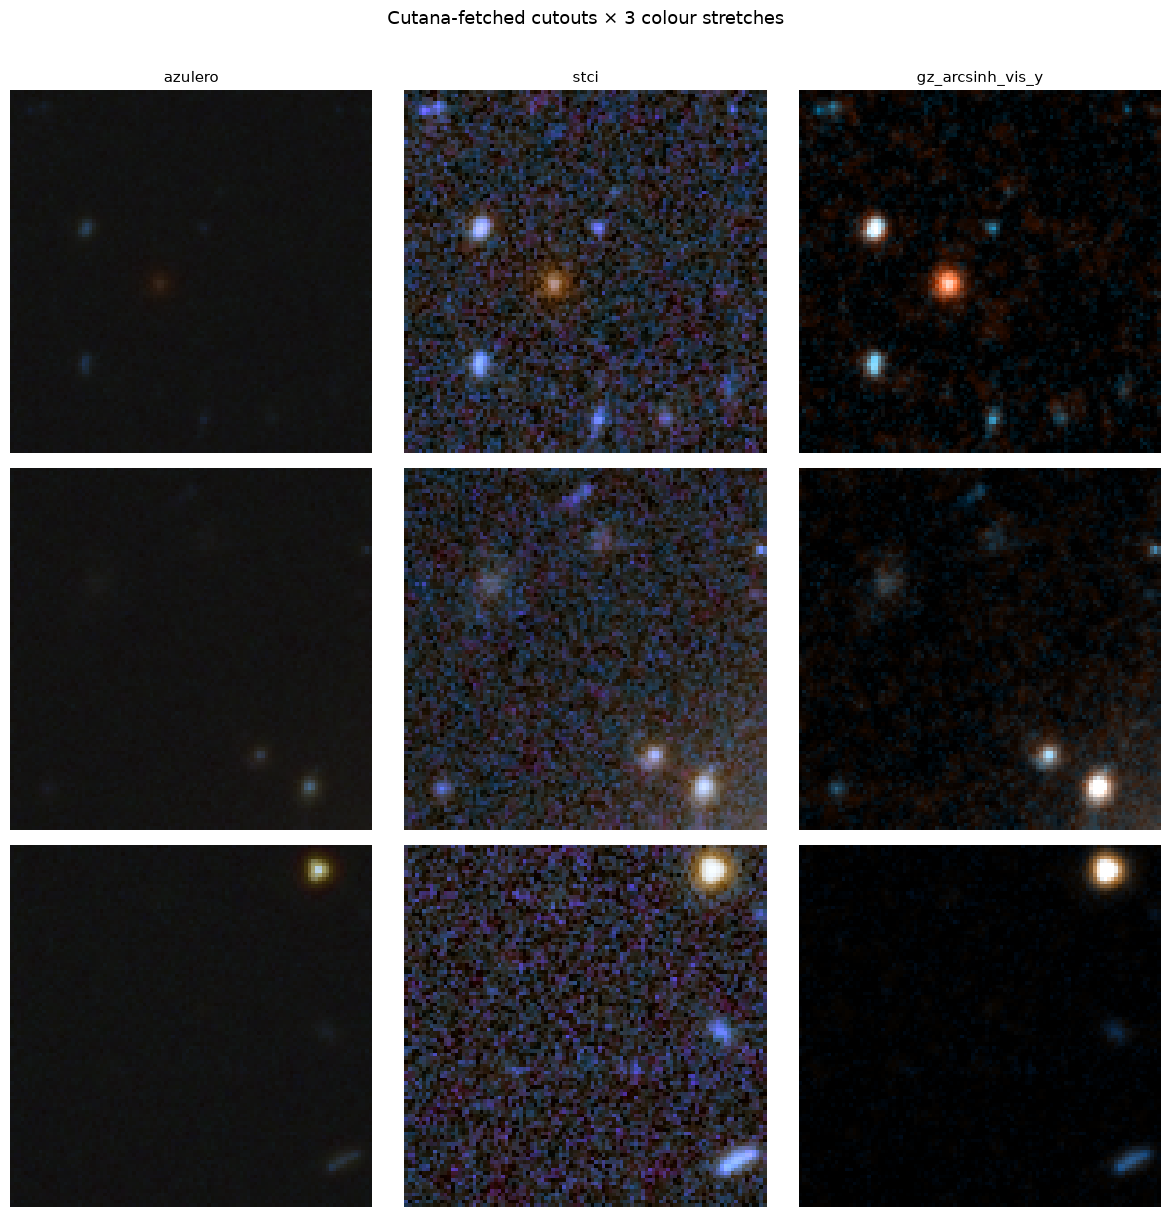

In [5]:
def to_iyjh(source_id: str) -> np.ndarray:
    raw = vis_y_j[source_id]
    iyjh = np.zeros((4,) + raw.shape[:2], dtype=np.float32)
    iyjh[0] = raw[..., 2]                  # VIS
    iyjh[1] = raw[..., 0]                  # NIR_Y
    iyjh[2] = raw[..., 1]                  # NIR_J
    iyjh[3] = nir_h[source_id][..., 0]     # NIR_H
    return iyjh


renderers = ["azulero", "stci", "gz_arcsinh_vis_y"]
stems = list(vis_y_j.keys())

fig, axes = plt.subplots(len(stems), len(renderers),
                         figsize=(4 * len(renderers), 4 * len(stems)))
for row, stem in enumerate(stems):
    iyjh = to_iyjh(stem)
    out = render_cutout(iyjh, renderers=["azulero", "stci", "bulk_euclid"],
                        bulk_variants=["gz_arcsinh_vis_y"], bulk_euclid_root=BULK_ROOT)
    for col, name in enumerate(renderers):
        axes[row, col].imshow(out[name])
        if row == 0:
            axes[row, col].set_title(name, fontsize=11)
        if col == 0:
            axes[row, col].set_ylabel(stem, fontsize=9)
        axes[row, col].axis("off")
plt.suptitle("Cutana-fetched cutouts × 3 colour stretches", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## Batch / file-based variant

For a larger batch you may want actual FITS files on disk (e.g. to hand off
to `render_fits_dir`, which parallelizes across files and skips ones
already rendered). Write each IYJH array out as a 4-extension FITS file
matching the format `load_fits_cutout` expects (`CHANNEL_1`..`CHANNEL_4` =
VIS, NIR-Y, NIR-J, NIR-H), then point `render_fits_dir` at that directory,
see `tutorial.ipynb`'s "FITS-input mode" section for that half of the
pipeline.


In [6]:
from astropy.io import fits

fits_out_dir = "cutana_fetched_fits"
os.makedirs(fits_out_dir, exist_ok=True)

for stem in vis_y_j:
    iyjh = to_iyjh(stem)
    hdus = [fits.PrimaryHDU()] + [fits.ImageHDU(data=iyjh[i], name=f"CHANNEL_{i + 1}")
                                  for i in range(4)]
    fits.HDUList(hdus).writeto(os.path.join(fits_out_dir, f"{stem}.fits"), overwrite=True)

print(f"Wrote {len(vis_y_j)} FITS files to {fits_out_dir}/")


Wrote 3 FITS files to cutana_fetched_fits/
